# Predicción de riesgo cardiovascular a 10 años — Análisis exploratorio de datos

**Entrega 1 (problema, dataset y EDA)**

El análisis se organiza en nueve secciones: contexto del problema, origen y descripción del
dataset, primera inspección, calidad de datos, variable objetivo, análisis univariado, análisis
bivariado, sesgo y *leakage*, y conclusiones con la propuesta de siguientes pasos. Cada figura o
tabla va seguida de su interpretación, con las cifras concretas que la sustentan.

## 0. Contexto y formulación del problema

**Motivación.** Las enfermedades cardiovasculares son la primera causa de muerte en el mundo: la
OMS estima cerca de 17,9 millones de fallecimientos anuales, alrededor del 32 % del total [4]. La
estrategia más costo-efectiva para reducir esa cifra no es diagnosticar a quien ya tiene síntomas,
sino **identificar a personas sanas con alto riesgo futuro** para intervenir a tiempo (cambios de
hábitos, control de presión o colesterol) antes de que ocurra un evento. Ese es precisamente el
problema de **tamizaje o prevención primaria**, distinto de un problema de *diagnóstico*.

**Por qué este dataset encaja con el problema.** El **Framingham Heart Study** es un estudio de
cohorte que reclutó personas de la comunidad, **sin enfermedad cardiovascular manifiesta** en el
momento del examen inicial, y las siguió en el tiempo para registrar quién desarrollaba la
enfermedad. Todas sus variables son obtenibles en un chequeo de rutina — no se requieren exámenes
invasivos ni de esfuerzo — y el objetivo, predecir un evento *futuro* y no uno ya ocurrido, es
exactamente el problema de tamizaje y prevención primaria planteado arriba.

**Tarea de Machine Learning.** Clasificación binaria supervisada, con un componente prospectivo:
dado el examen basal de un paciente (15 atributos demográficos, de hábitos y clínicos, medidos en
un único punto en el tiempo), predecir la variable `TenYearCHD`, que vale 1 si esa persona
desarrolló enfermedad coronaria dentro de los 10 años siguientes al examen, y 0 si no.

**Preguntas de investigación (borrador).**

1. ¿Qué variables medibles en un chequeo de rutina — sin exámenes invasivos ni de esfuerzo —
   discriminan mejor el riesgo de enfermedad coronaria a 10 años, y son coherentes con los
   factores de riesgo cardiovascular documentados en la literatura?
2. ¿Un modelo lineal (regresión logística, en la línea del score de riesgo de Framingham
   original) alcanza un desempeño comparable al de modelos no lineales, o estos últimos aportan
   una mejora significativa dado el tamaño y el desbalance del conjunto?
3. ¿Cómo afectan el fuerte desbalance de clases (~15 % de casos positivos) y los patrones de
   valores faltantes al desempeño, la calibración de las probabilidades estimadas y la equidad
   del modelo entre subgrupos (sexo, nivel educativo)?

Las preguntas 2 y 3 se responden con evidencia experimental en la Entrega 2; este notebook aporta
la evidencia descriptiva necesaria para plantearlas correctamente.

## 1. Origen y descripción del dataset

El **Framingham Heart Study** es el estudio de cohorte cardiovascular más influyente de la
historia de la epidemiología. Comenzó en 1948 en el pueblo de Framingham, Massachusetts (EE. UU.):
se reclutaron **5 209 adultos de 28 a 62 años, libres de enfermedad cardiovascular manifiesta en
ese momento**, alrededor de dos tercios de la población adulta del pueblo, captados puerta a
puerta y no a través de un hospital [1]. Fue este estudio el que, en los años 60, estableció por
primera vez con evidencia longitudinal que el colesterol, la presión arterial y el tabaquismo son
*factores de riesgo* de enfermedad cardíaca — el origen del propio concepto.

El archivo `framingham.csv` es un subconjunto curado, ampliamente utilizado en cursos de ciencia
de datos y disponible en Kaggle [2], con **4 240 observaciones y 16 columnas** (15 predictores +
la variable objetivo). El rango de edad de este subconjunto (32–70 años) es ligeramente superior
al de la cohorte original en su reclutamiento (28–62), lo que sugiere que corresponde a un examen
de seguimiento posterior de los mismos participantes, y no al primer examen de 1948. La
redistribución en Kaggle no especifica una licencia formal; los datos originales pertenecen al
Framingham Heart Study / NIH-NHLBI y su uso en investigación real requiere solicitud a través de
BioLINCC. Aquí se usa exclusivamente con fines académicos, como es habitual con este subconjunto
en la docencia de ML.

### Diccionario de variables

| Variable | Tipo | Valores / unidad | Significado clínico | Rol |
| --- | --- | --- | --- | --- |
| `male` | binaria | 1 = hombre, 0 = mujer | Sexo | feature |
| `age` | numérica (entero) | años | Edad en el examen basal | feature |
| `education` | ordinal | 1–4 | Nivel educativo (proxy socioeconómico; 1 = menor, 4 = mayor) | feature |
| `currentSmoker` | binaria | 1 = sí, 0 = no | Fumador activo | feature |
| `cigsPerDay` | numérica | cigarrillos/día | Consumo diario de tabaco (0 si no fuma) | feature |
| `BPMeds` | binaria | 1 = sí, 0 = no | Toma medicación antihipertensiva | feature |
| `prevalentStroke` | binaria | 1 = sí, 0 = no | ACV previo | feature |
| `prevalentHyp` | binaria | 1 = sí, 0 = no | Hipertenso al momento del examen | feature |
| `diabetes` | binaria | 1 = sí, 0 = no | Diabetes diagnosticada | feature |
| `totChol` | numérica | mg/dL | Colesterol total | feature |
| `sysBP` | numérica | mm Hg | Presión arterial sistólica | feature |
| `diaBP` | numérica | mm Hg | Presión arterial diastólica | feature |
| `BMI` | numérica | kg/m² | Índice de masa corporal | feature |
| `heartRate` | numérica | latidos/min | Frecuencia cardíaca en reposo | feature |
| `glucose` | numérica | mg/dL | Glucosa en sangre | feature |
| `TenYearCHD` | binaria | 1 = evento, 0 = sin evento | **Variable objetivo**: ¿desarrolló enfermedad coronaria en los 10 años siguientes? | target |

**Todas** las variables se miden en el examen basal, antes de que exista cualquier evidencia del
desenlace: por construcción, ninguna presupone sospecha clínica previa. Esta característica se
retoma en la sección 7.

In [1]:
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from nb_utils import use_style, COLORBLIND_CYCLE   # estilo de gráficos del curso
use_style("notes")
pd.set_option("display.precision", 3)
pd.set_option("display.max_columns", 20)

DATA = Path("../data/framingham.csv")
FIG = Path("../figures")
FIG.mkdir(exist_ok=True)

TARGET = "TenYearCHD"
NUM = ["age", "totChol", "sysBP", "diaBP", "BMI", "heartRate", "glucose", "cigsPerDay"]
BIN = ["male", "currentSmoker", "BPMeds", "prevalentStroke", "prevalentHyp", "diabetes"]
ORD = ["education"]

ETIQUETAS = {
    "age": "edad (años)", "totChol": "colesterol total (mg/dL)", "sysBP": "presión sistólica (mm Hg)",
    "diaBP": "presión diastólica (mm Hg)", "BMI": "índice de masa corporal (kg/m²)",
    "heartRate": "frecuencia cardíaca en reposo (lpm)", "glucose": "glucosa (mg/dL)",
    "cigsPerDay": "cigarrillos por día", "male": "sexo (1 = hombre)", "currentSmoker": "fumador activo",
    "BPMeds": "medicación antihipertensiva", "prevalentStroke": "ACV previo", "prevalentHyp": "hipertensión previa",
    "diabetes": "diabetes", "education": "nivel educativo (1-4)", "TenYearCHD": "enfermedad coronaria a 10 años",
}
C0, C1 = "#0072B2", "#D55E00"       # color clase 0 (sin evento) / clase 1 (con evento)

def guardar(fig, nombre):
    fig.savefig(FIG / nombre)
    plt.show()

raw = pd.read_csv(DATA)
print("dataset:", raw.shape[0], "participantes x", raw.shape[1], "columnas")

dataset: 4240 participantes x 16 columnas


## 2. Primera inspección

La inspección inicial combina `.head()`, `.info()` y `.describe()`. Conviene comprobar primero si
`.info()` detecta los faltantes, porque de eso depende cómo se interpreta el resto del
diagnóstico.

In [2]:
raw.head()

,male,age,education,currentSmoker,cigsPerDay,BPMeds,prevalentStroke,prevalentHyp,diabetes,totChol,sysBP,diaBP,BMI,heartRate,glucose,TenYearCHD
0,1,39,4.0,0,0.0,0.0,0,0,0,195.0,106.0,70.0,26.97,80.0,77.0,0
1,0,46,2.0,0,0.0,0.0,0,0,0,250.0,121.0,81.0,28.73,95.0,76.0,0
2,1,48,1.0,1,20.0,0.0,0,0,0,245.0,127.5,80.0,25.34,75.0,70.0,0
3,0,61,3.0,1,30.0,0.0,0,1,0,225.0,150.0,95.0,28.58,65.0,103.0,1
4,0,46,3.0,1,23.0,0.0,0,0,0,285.0,130.0,84.0,23.10,85.0,85.0,0


In [3]:
raw.info()

<class 'pandas.DataFrame'>
RangeIndex: 4240 entries, 0 to 4239
Data columns (total 16 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   male             4240 non-null   int64  
 1   age              4240 non-null   int64  
 2   education        4135 non-null   float64
 3   currentSmoker    4240 non-null   int64  
 4   cigsPerDay       4211 non-null   float64
 5   BPMeds           4187 non-null   float64
 6   prevalentStroke  4240 non-null   int64  
 7   prevalentHyp     4240 non-null   int64  
 8   diabetes         4240 non-null   int64  
 9   totChol          4190 non-null   float64
 10  sysBP            4240 non-null   float64
 11  diaBP            4240 non-null   float64
 12  BMI              4221 non-null   float64
 13  heartRate        4239 non-null   float64
 14  glucose          3852 non-null   float64
 15  TenYearCHD       4240 non-null   int64  
dtypes: float64(9), int64(7)
memory usage: 530.1 KB


`.info()` delata los faltantes directamente: siete columnas tienen menos de 4 240 valores no
nulos (`education`, `cigsPerDay`, `BPMeds`, `totChol`, `BMI`, `heartRate`, `glucose`). Son
faltantes explícitos (`NaN`) — la comprobación estándar basta para encontrarlos, aunque falta
cuantificarlos y entender su mecanismo (sección 3).

In [4]:
raw[NUM].describe().T.round(2)

,count,mean,std,min,25%,50%,75%,max
age,4240.0,49.58,8.57,32.00,42.00,49.0,56.00,70.0
totChol,4190.0,236.70,44.59,107.00,206.00,234.0,263.00,696.0
sysBP,4240.0,132.35,22.03,83.50,117.00,128.0,144.00,295.0
diaBP,4240.0,82.90,11.91,48.00,75.00,82.0,90.00,142.5
BMI,4221.0,25.80,4.08,15.54,23.07,25.4,28.04,56.8
heartRate,4239.0,75.88,12.03,44.00,68.00,75.0,83.00,143.0
glucose,3852.0,81.96,23.95,40.00,71.00,78.0,87.00,394.0
cigsPerDay,4211.0,9.01,11.92,0.00,0.00,0.0,20.00,70.0


In [5]:
raw[BIN + ORD + [TARGET]].describe().T.round(2)

,count,mean,std,min,25%,50%,75%,max
male,4240.0,0.43,0.50,0.0,0.0,0.0,1.0,1.0
currentSmoker,4240.0,0.49,0.50,0.0,0.0,0.0,1.0,1.0
BPMeds,4187.0,0.03,0.17,0.0,0.0,0.0,0.0,1.0
prevalentStroke,4240.0,0.01,0.08,0.0,0.0,0.0,0.0,1.0
prevalentHyp,4240.0,0.31,0.46,0.0,0.0,0.0,1.0,1.0
diabetes,4240.0,0.03,0.16,0.0,0.0,0.0,0.0,1.0
education,4135.0,1.98,1.02,1.0,1.0,2.0,3.0,4.0
TenYearCHD,4240.0,0.15,0.36,0.0,0.0,0.0,0.0,1.0


El resumen numérico no muestra valores imposibles evidentes: no hay ceros ni negativos en
variables donde eso sería absurdo. La edad va de 32 a 70 años, dentro del rango de la cohorte;
las presiones y el colesterol tienen máximos
altos pero clínicamente plausibles. La excepción es **`glucose`**, cuyo máximo de 394 mg/dL frente
a una mediana de 78 sugiere una cola larga que se examina en la sección 5. Las binarias están
todas codificadas como 0/1 y `education` como 1–4, sin valores fuera de rango.

## 3. Calidad de datos

### 3.1 Valores nulos y duplicados

In [6]:
miss = raw.isna().sum()
tabla_miss = pd.DataFrame({"n faltantes": miss[miss > 0], "% del total": (100 * miss[miss > 0] / len(raw)).round(2)})
tabla_miss = tabla_miss.sort_values("n faltantes", ascending=False)
print("filas duplicadas exactas:", raw.duplicated().sum())
print(f"filas con al menos un faltante: {raw.isna().any(axis=1).sum()} ({100*raw.isna().any(axis=1).mean():.2f} %)")
tabla_miss

filas duplicadas exactas: 0
filas con al menos un faltante: 582 (13.73 %)


,n faltantes,% del total
glucose,388,9.15
education,105,2.48
BPMeds,53,1.25
totChol,50,1.18
cigsPerDay,29,0.68
BMI,19,0.45
heartRate,1,0.02


No hay filas duplicadas. Sí hay faltantes reales en siete de las quince variables, que afectan al
**13,73 % de las filas** (582 de 4 240). La variable más afectada es `glucose`, con 388 faltantes
(9,15 %); le siguen `education` (105, 2,48 %), `BPMeds` (53, 1,25 %), `totChol` (50, 1,18 %),
`cigsPerDay` (29, 0,68 %), `BMI` (19, 0,45 %) y `heartRate` (1 caso aislado). Ninguna columna
supera el 10 % de faltantes por separado, un panorama bastante más manejable que el del dataset
descartado, donde una sola variable concentraba casi el 19 % en valores no aleatorios.

### 3.2 Comprobaciones de dominio

In [7]:
chequeos = {
    "diaBP > sysBP (imposible)":                    (raw["diaBP"] > raw["sysBP"]).sum(),
    "sysBP > 250 (extremo)":                         (raw["sysBP"] > 250).sum(),
    "totChol > 500 (extremo)":                       (raw["totChol"] > 500).sum(),
    "glucose > 300 (extremo)":                       (raw["glucose"] > 300).sum(),
    "BMI < 15 o > 50 (extremo)":                     ((raw["BMI"] < 15) | (raw["BMI"] > 50)).sum(),
    "fumador (currentSmoker=1) con cigsPerDay = 0":  ((raw["currentSmoker"] == 1) & (raw["cigsPerDay"] == 0)).sum(),
    "no fumador (currentSmoker=0) con cigsPerDay > 0": ((raw["currentSmoker"] == 0) & (raw["cigsPerDay"] > 0)).sum(),
    "edad fuera de [28, 70]":                        ((raw["age"] < 28) | (raw["age"] > 70)).sum(),
}
pd.DataFrame({"n filas": pd.Series(chequeos)}).assign(**{"% del total": lambda d: (100 * d["n filas"] / len(raw)).round(2)})

,n filas,% del total
diaBP > sysBP (imposible),0,0.00
sysBP > 250 (extremo),1,0.02
totChol > 500 (extremo),2,0.05
glucose > 300 (extremo),9,0.21
BMI < 15 o > 50 (extremo),2,0.05
fumador (currentSmoker=1) con cigsPerDay = 0,0,0.00
no fumador (currentSmoker=0) con cigsPerDay > 0,0,0.00
"edad fuera de [28, 70]",0,0.00


La consistencia interna es notable: es perfecta en los dos chequeos cruzados. **Ningún** registro tiene la presión diastólica mayor que
la sistólica, y **ningún** fumador declara 0 cigarrillos ni ningún no fumador declara un consumo
positivo — las variables `currentSmoker` y `cigsPerDay` son mutuamente consistentes en los 4 240
casos. Los únicos valores señalados son extremos altos y aislados (1 presión sistólica > 250, 2
colesteroles > 500, 9 glucosas > 300, 2 IMC > 50), que se evalúan como posibles atípicos —no como
errores— en la sección 5.2.

### 3.3 ¿Por qué faltan los datos? El mecanismo importa

Conviene plantear esta pregunta con los tres faltantes más frecuentes: ¿el faltante se relaciona
con la edad, el sexo o, sobre todo, con el propio desenlace? La respuesta determina si basta una
imputación simple o si conviene condicionarla en otras variables observadas.

In [8]:
def perfil_faltante(col):
    falta = raw[col].isna()
    return pd.Series({
        "n faltantes": falta.sum(),
        "edad media (falta)": raw.loc[falta, "age"].mean(), "edad media (no falta)": raw.loc[~falta, "age"].mean(),
        "% hombres (falta)": 100 * raw.loc[falta, "male"].mean(), "% hombres (no falta)": 100 * raw.loc[~falta, "male"].mean(),
        "tasa CHD (falta)": raw.loc[falta, TARGET].mean(), "tasa CHD (no falta)": raw.loc[~falta, TARGET].mean(),
    })

pd.DataFrame({c: perfil_faltante(c) for c in ["glucose", "BPMeds", "education", "totChol", "cigsPerDay", "BMI"]}).T.round(3)

,n faltantes,edad media (falta),edad media (no falta),% hombres (falta),% hombres (no falta),tasa CHD (falta),tasa CHD (no falta)
glucose,388.0,49.000,49.639,29.639,44.263,0.129,0.154
BPMeds,53.0,53.491,49.531,28.302,43.110,0.208,0.151
education,105.0,50.676,49.552,50.476,42.733,0.152,0.152
totChol,50.0,51.480,49.558,14.000,43.270,0.180,0.152
cigsPerDay,29.0,49.345,49.582,48.276,42.888,0.069,0.152
BMI,19.0,51.632,49.571,26.316,42.999,0.526,0.150


El patrón hay que leerlo con matices:

* **`glucose` (9,15 % de faltantes)**: el grupo con glucosa no medida tiene **menos** hombres
  (29,6 % frente a 44,3 %) y una tasa de enfermedad ligeramente **menor** (12,9 % frente a
  15,4 %) — lo opuesto a lo que se vería si el faltante escondiera casos más graves. El patrón
  sugiere que faltar depende de **quién fue examinado** (más asociado al sexo que al desenlace),
  compatible con un mecanismo **MAR** (falta al azar condicional a variables observadas), no MNAR.
* **`BPMeds` (1,25 %)**: el grupo con este dato faltante es 4 años mayor en promedio (53,5 frente
  a 49,5) y tiene una tasa de enfermedad más alta (20,8 % frente a 15,1 %). Aquí sí hay un indicio
  de asociación con el desenlace, aunque con apenas 53 casos el margen de error es amplio.
* **`totChol`, `education`, `cigsPerDay`, `BMI`**: diferencias pequeñas e inconsistentes en
  dirección, sin un patrón claro; con `BMI` en particular (sólo 19 casos) cualquier diferencia
  porcentual es ruidosa y no debe sobreinterpretarse.

La conclusión práctica es que **no hay evidencia fuerte de que el faltante en sí mismo sea un
atajo para predecir el desenlace** (salvo, con cautela, en `BPMeds`). Esto reduce el riesgo de
que un indicador de "faltante" actúe como fuga de información, pero no
elimina la necesidad de imputar con cuidado: como el faltante en `glucose` se relaciona con el
sexo, conviene imputar condicionando en variables observadas (por ejemplo, la mediana por sexo)
en vez de una mediana global, y hacerlo siempre dentro del pipeline, ajustado sólo con el
conjunto de entrenamiento.

## 4. Variable objetivo

Al tratarse de una población general seguida en el tiempo, es esperable que la gran mayoría **no**
desarrolle un evento coronario dentro de la ventana de 10 años.

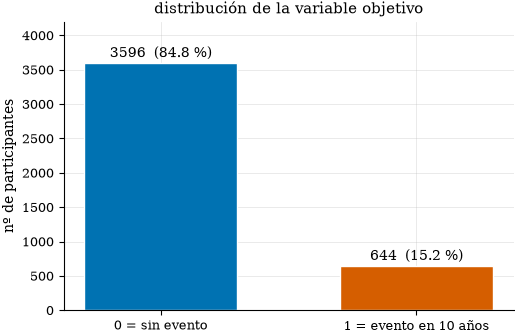

exactitud de predecir siempre la clase mayoritaria (0): 0.8481


In [9]:
conteo = raw[TARGET].value_counts().sort_index()
prop = raw[TARGET].value_counts(normalize=True).sort_index()

fig, ax = plt.subplots(figsize=(5.2, 3.4))
ax.bar(["0 = sin evento", "1 = evento en 10 años"], conteo.values, color=[C0, C1], edgecolor="white", width=0.6)
for i, (n, p) in enumerate(zip(conteo.values, prop.values)):
    ax.text(i, n + 40, f"{n}  ({100*p:.1f} %)", ha="center", va="bottom")
ax.set_ylim(0, 4200); ax.set_ylabel("nº de participantes"); ax.set_title("distribución de la variable objetivo")
guardar(fig, "01-target.png")

print(f"exactitud de predecir siempre la clase mayoritaria (0): {prop.max():.4f}")

De 4 240 participantes, 644 (15,19 %) desarrollaron enfermedad coronaria en los 10 años
siguientes y 3 596 (84,81 %) no. La razón entre clases es de 5,6 : 1 — un desbalance real y considerable.

Esto tiene una consecuencia importante: la **línea base trivial** — predecir siempre "sin evento" — alcanza una exactitud del **84,8 %**.
Ese número *suena* bueno, pero corresponde a un modelo completamente inútil: nunca identifica a
una sola persona en riesgo, que es justo lo que un sistema de tamizaje necesita hacer. Por eso, en
la Entrega 2, la exactitud no puede ser el criterio de éxito; se necesitan métricas sensibles a la
clase minoritaria (**recall**, **F1**, **PR-AUC**) y, dado que el objetivo es una probabilidad de
riesgo y no sólo una etiqueta, también será relevante evaluar la **calibración** del modelo (si
"30 % de riesgo estimado" corresponde de verdad a que 3 de cada 10 personas con ese puntaje
desarrollan la enfermedad).

## 5. Análisis univariado

### 5.1 Variables numéricas

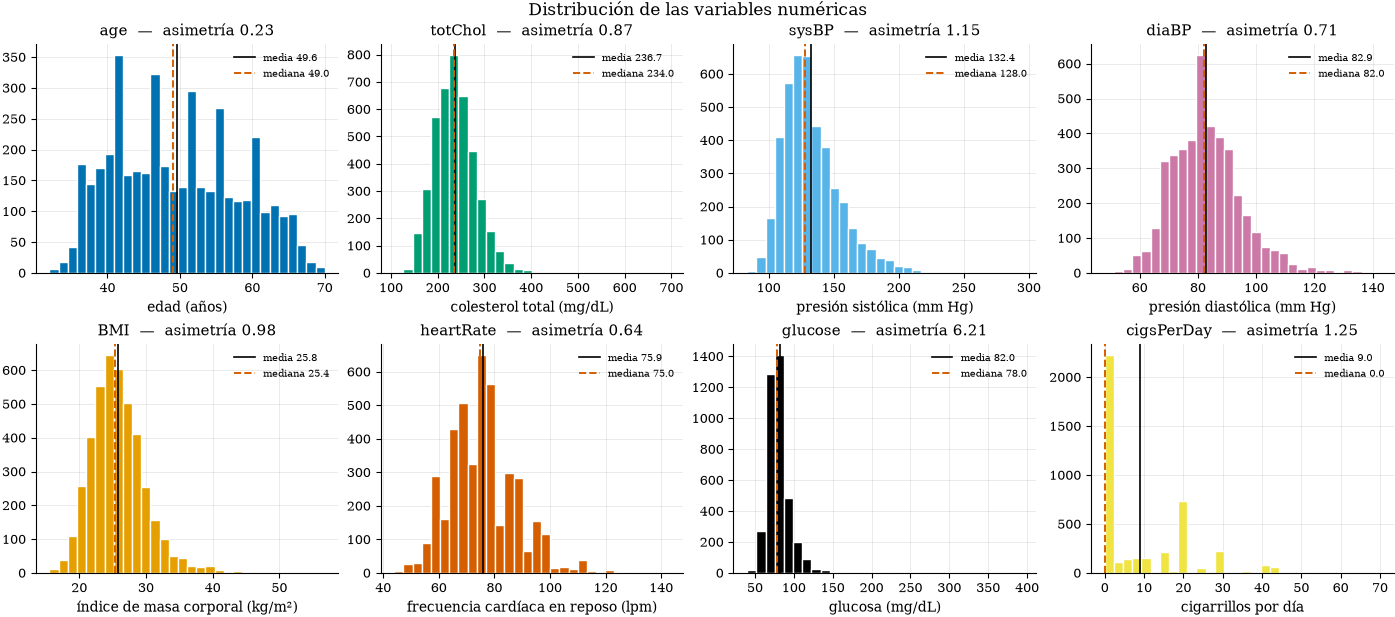

In [10]:
fig, axes = plt.subplots(2, 4, figsize=(14, 6))
colores = ["#0072B2", "#009E73", "#56B4E9", "#CC79A7", "#E69F00", "#D55E00", "#000000", "#F0E442"]

for ax, col, color in zip(axes.ravel(), NUM, colores):
    s = raw[col].dropna()
    ax.hist(s, bins=30, color=color, edgecolor="white")
    ax.axvline(s.mean(), color="black", ls="-", lw=1.2, label=f"media {s.mean():.1f}")
    ax.axvline(s.median(), color=C1, ls="--", lw=1.4, label=f"mediana {s.median():.1f}")
    ax.set_title(f"{col}  —  asimetría {s.skew():.2f}")
    ax.set_xlabel(ETIQUETAS[col]); ax.legend(fontsize=7.5)

fig.suptitle("Distribución de las variables numéricas", y=1.03)
guardar(fig, "02-hist-numericas.png")

Ocho formas distintas, casi todas con cola derecha, esperable en variables clínicas que no pueden
ser negativas:

* **`age`** es casi simétrica (asimetría 0,23), centrada en 49 años, rango 32–70.
* **`sysBP`** (1,15) y **`diaBP`** (0,71) muestran cola derecha moderada: la mayoría se concentra
  entre 117–144 (sistólica) y 75–90 (diastólica) mm Hg, con una cola de valores hipertensos.
* **`totChol`** (0,87) y **`BMI`** (0,98) tienen colas derechas similares, coherentes con la
  distribución habitual de estas variables en poblaciones adultas.
* **`heartRate`** es la más simétrica de las siete continuas después de la edad (0,64).
* **`cigsPerDay`** (1,25) tiene una masa grande en 0 (no fumadores, el 50,6 % del total) y una
  cola de fumadores que llega hasta 70 cigarrillos/día.
* **`glucose`** es, por lejos, la más asimétrica: **asimetría 6,21 y curtosis 58,7**, muy por
  encima del resto. La mediana es 78 mg/dL pero el máximo llega a 394 — una cola extrema que
  corresponde, con toda probabilidad, a un pequeño grupo de personas con diabetes no controlada
  (la correlación `glucose`–`diabetes` es de 0,62, la más alta del conjunto tras las estructurales
  de presión). Un histograma en escala lineal como el de arriba comprime casi toda la variable
  contra el cero; en el modelado esto pesará más en variantes de escalado sensibles a la escala
  (`StandardScaler`) que en una basada en rango o en árboles.

### 5.2 Valores atípicos

In [11]:
def limites_iqr(s):
    q1, q3 = s.quantile(0.25), s.quantile(0.75)
    iqr = q3 - q1
    return q1 - 1.5 * iqr, q3 + 1.5 * iqr

filas = []
for col in NUM:
    s = raw[col].dropna()
    lo, hi = limites_iqr(s)
    n = ((s < lo) | (s > hi)).sum()
    filas.append({"variable": col, "límite inferior": round(lo, 1), "límite superior": round(hi, 1),
                  "mínimo": s.min(), "máximo": s.max(), "n atípicos": n, "% atípicos": round(100 * n / len(s), 2)})
pd.DataFrame(filas).set_index("variable")

,límite inferior,límite superior,mínimo,máximo,n atípicos,% atípicos
variable,,,,,,
age,21.0,77.0,32.00,70.0,0,0.00
totChol,120.5,348.5,107.00,696.0,56,1.34
sysBP,76.5,184.5,83.50,295.0,126,2.97
diaBP,52.5,112.5,48.00,142.5,77,1.82
BMI,15.6,35.5,15.54,56.8,97,2.30
heartRate,45.5,105.5,44.00,143.0,76,1.79
glucose,47.0,111.0,40.00,394.0,188,4.88
cigsPerDay,-30.0,50.0,0.00,70.0,12,0.28


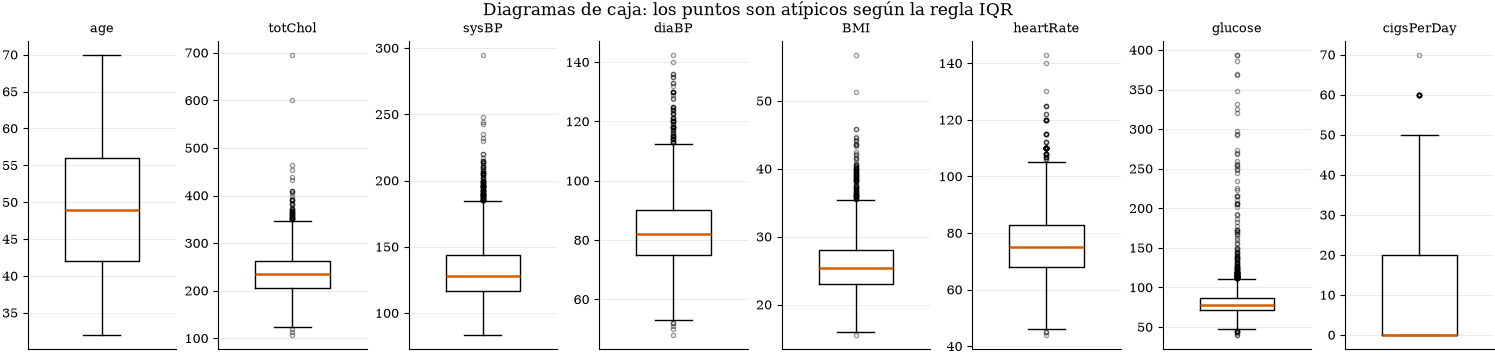

In [12]:
fig, axes = plt.subplots(1, 8, figsize=(15, 3.4))
for ax, col in zip(axes, NUM):
    s = raw[col].dropna()
    ax.boxplot(s, widths=0.5, medianprops=dict(color=C1, lw=1.8),
               flierprops=dict(marker="o", markersize=3, alpha=0.4))
    ax.set_xticks([]); ax.set_title(col, fontsize=9)
fig.suptitle("Diagramas de caja: los puntos son atípicos según la regla IQR", y=1.05)
guardar(fig, "03-boxplots-iqr.png")

La incidencia de atípicos va de casi nula (`age`, 0 %) a moderada (`glucose`, 4,88 %, la más alta,
coherente con su fuerte asimetría). `sysBP` (2,97 %), `BMI` (2,30 %), `diaBP` (1,82 %),
`heartRate` (1,79 %) y `totChol` (1,34 %) están en un rango bajo y esperable. `cigsPerDay` marca
sólo 12 casos (0,28 %) — fumadores muy intensos, por encima de 50 cigarrillos/día.

Como en el caso anterior, estos valores no son errores evidentes: una glucosa de 394 mg/dL es
compatible con diabetes descompensada, un IMC de 56,8 con obesidad severa, y una presión sistólica
de 295 con una crisis hipertensiva — todos, cuadros clínicos reales, no artefactos de captura. La
decisión es **conservarlos**. Sí es un motivo adicional, junto con la escala de `glucose`, para
preferir modelos o escalados robustos a la cola (RobustScaler, o modelos de árboles que son
invariantes a estas transformaciones) frente a un StandardScaler ingenuo.

### 5.3 Variables binarias y ordinal

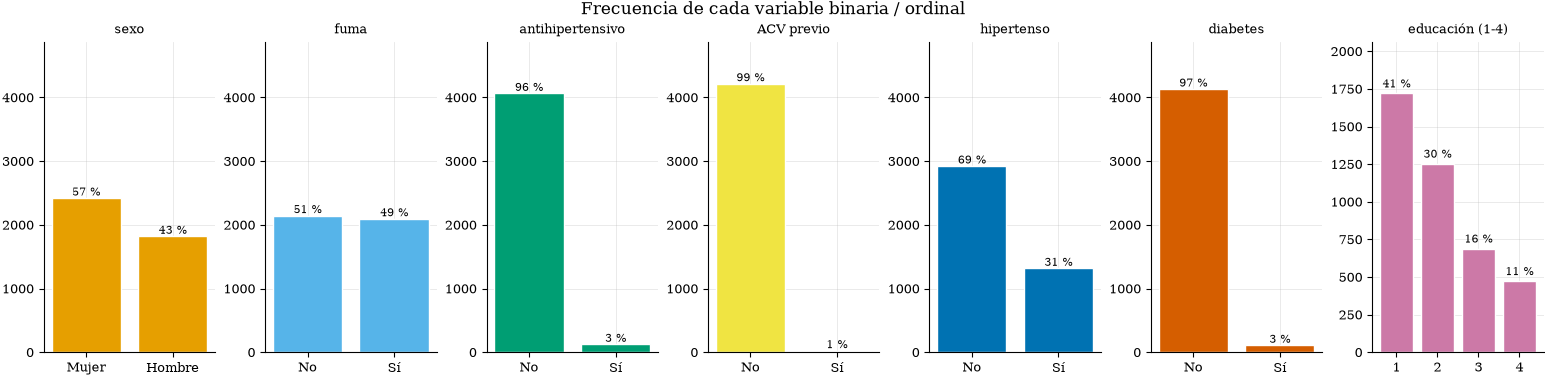

In [13]:
fig, axes = plt.subplots(1, 7, figsize=(15.5, 3.6))
etiquetas_cortas = {"male": "sexo", "currentSmoker": "fuma", "BPMeds": "antihipertensivo",
                     "prevalentStroke": "ACV previo", "prevalentHyp": "hipertenso", "diabetes": "diabetes"}
for ax, col, color in zip(axes[:6], BIN, COLORBLIND_CYCLE[1:7]):
    vc = raw[col].value_counts().reindex([0, 1])
    ax.bar(["No", "Sí"] if col != "male" else ["Mujer", "Hombre"], vc.values, color=color, edgecolor="white")
    for i, n in enumerate(vc.values):
        ax.text(i, n + 40, f"{100*n/len(raw):.0f} %", ha="center", fontsize=8)
    ax.set_title(etiquetas_cortas[col], fontsize=9); ax.set_ylim(0, raw.shape[0] * 1.15)

ax = axes[6]
vc = raw["education"].value_counts().sort_index()
ax.bar(vc.index.astype(int).astype(str), vc.values, color=COLORBLIND_CYCLE[7], edgecolor="white")
for i, n in enumerate(vc.values):
    ax.text(i, n + 40, f"{100*n/len(raw):.0f} %", ha="center", fontsize=8)
ax.set_title("educación (1-4)", fontsize=9); ax.set_ylim(0, vc.max() * 1.2)

fig.suptitle("Frecuencia de cada variable binaria / ordinal", y=1.05)
guardar(fig, "04-categoricas.png")

Algunos puntos a destacar:

* **`male`**: la muestra está razonablemente equilibrada, 42,9 % hombres (1 820) y 57,1 % mujeres
  (2 420).
* **`currentSmoker`**: 49,4 % fuma activamente — una prevalencia altísima para hoy (la tasa actual
  de tabaquismo en adultos de EE. UU. ronda el 11-12 %), reflejo de la época del estudio. Entre
  quienes fuman, el consumo medio es de 18,4 cigarrillos/día. Se retoma en la sección 7 como sesgo
  temporal.
* **`BPMeds`** (2,9 %), **`prevalentStroke`** (0,6 %) y **`diabetes`** (2,6 %) son condiciones
  poco frecuentes en esta población basal — esperable, dado que son personas de la comunidad, no
  pacientes hospitalarios. Su rareza implica que las estimaciones de su efecto tendrán más
  incertidumbre.
* **`prevalentHyp`**: 31,1 % de la muestra ya era hipertensa en el examen inicial — la condición
  previa más común, y una de las más relacionadas con el desenlace (sección 6).
* **`education`**: la categoría más baja (1) concentra el 40,6 % de la muestra; las categorías
  superiores son progresivamente menos frecuentes.

## 6. Análisis bivariado: ¿qué se relaciona con el riesgo?

### 6.1 Variables numéricas por clase

In [14]:
sd_total = raw[NUM].std()
medias = raw.groupby(TARGET)[NUM].mean()
efecto = ((medias.loc[1] - medias.loc[0]) / sd_total).round(3).rename("diferencia de medias (en DE)")
print("diferencia de medias entre clases, en desviaciones estándar:")
print(efecto.sort_values(key=np.abs, ascending=False).to_string())
raw.groupby(TARGET)[NUM].agg(["mean", "median"]).T.round(2)

diferencia de medias entre clases, en desviaciones estándar:
age           0.628
sysBP         0.603
diaBP         0.404
glucose       0.348
totChol       0.230
BMI           0.211
cigsPerDay    0.161
heartRate     0.064


TenYearCHD              0       1
age        mean     48.76   54.15
           median   48.00   55.00
totChol    mean    235.15  245.39
           median  232.00  241.00
sysBP      mean    130.34  143.62
           median  127.00  139.00
diaBP      mean     82.17   86.98
           median   81.00   85.50
BMI        mean     25.67   26.53
           median   25.25   26.16
heartRate  mean     75.76   76.53
           median   75.00   75.00
glucose    mean     80.68   89.01
           median   78.00   79.00
cigsPerDay mean      8.71   10.63
           median    0.00    2.50

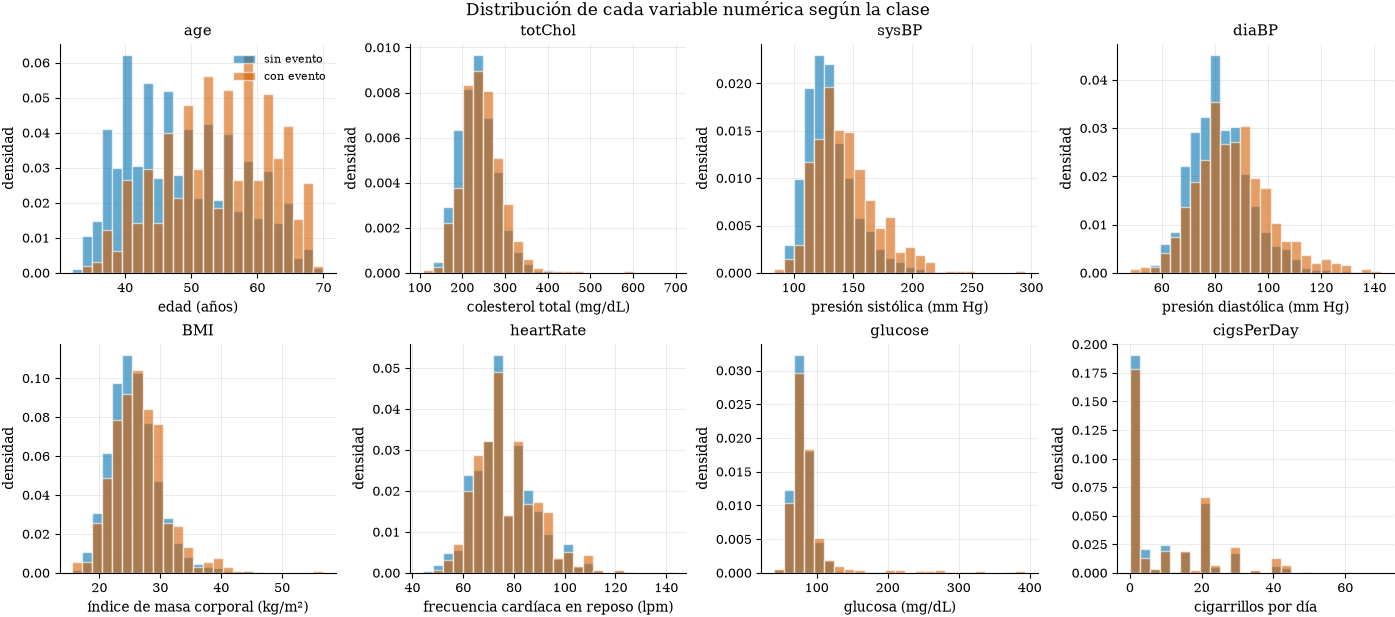

In [15]:
fig, axes = plt.subplots(2, 4, figsize=(14, 6))
for ax, col in zip(axes.ravel(), NUM):
    d = raw.dropna(subset=[col])
    bins = np.histogram_bin_edges(d[col], bins=25)
    ax.hist(d.loc[d[TARGET] == 0, col], bins=bins, alpha=0.6, color=C0, edgecolor="white", label="sin evento", density=True)
    ax.hist(d.loc[d[TARGET] == 1, col], bins=bins, alpha=0.6, color=C1, edgecolor="white", label="con evento", density=True)
    ax.set_xlabel(ETIQUETAS[col]); ax.set_ylabel("densidad"); ax.set_title(col)
axes[0, 0].legend(fontsize=8)
fig.suptitle("Distribución de cada variable numérica según la clase", y=1.03)
guardar(fig, "05-numericas-por-clase.png")

Las diferencias entre clases son moderadas — esperable, porque se está prediciendo un evento diez
años en el futuro, no una condición ya presente. Aun así hay un orden claro:

* **`age` (+0,63 DE)** y **`sysBP` (+0,60 DE)** son las dos más discriminantes. Quienes desarrollan
  el evento son en promedio 5,4 años mayores en el examen basal (54,2 frente a 48,8) y tienen una
  presión sistólica 13 mm Hg más alta (143,6 frente a 130,3). Es el resultado más citado de la
  literatura de Framingham: edad y presión arterial son, con diferencia, los predictores más
  fuertes de riesgo coronario.
* **`diaBP` (+0,40 DE)** y **`glucose` (+0,35 DE)** siguen en magnitud.
* **`totChol` (+0,23 DE)**, **`BMI` (+0,21 DE)** y **`cigsPerDay` (+0,16 DE)** tienen efectos
  moderados: el colesterol medio es apenas 10 mg/dL mayor en quienes desarrollan el evento
  (245,4 frente a 235,2), y el consumo de tabaco es sólo algo mayor en promedio (10,6 frente a
  8,7 cigarrillos/día) — una diferencia menor a la que la literatura médica atribuiría al
  tabaquismo, un punto que se retoma en la sección 6.3.
* **`heartRate` (+0,06 DE)** es la más débil de las ocho: prácticamente no distingue entre clases.

### 6.2 Variables binarias y ordinal: tasa de evento por categoría

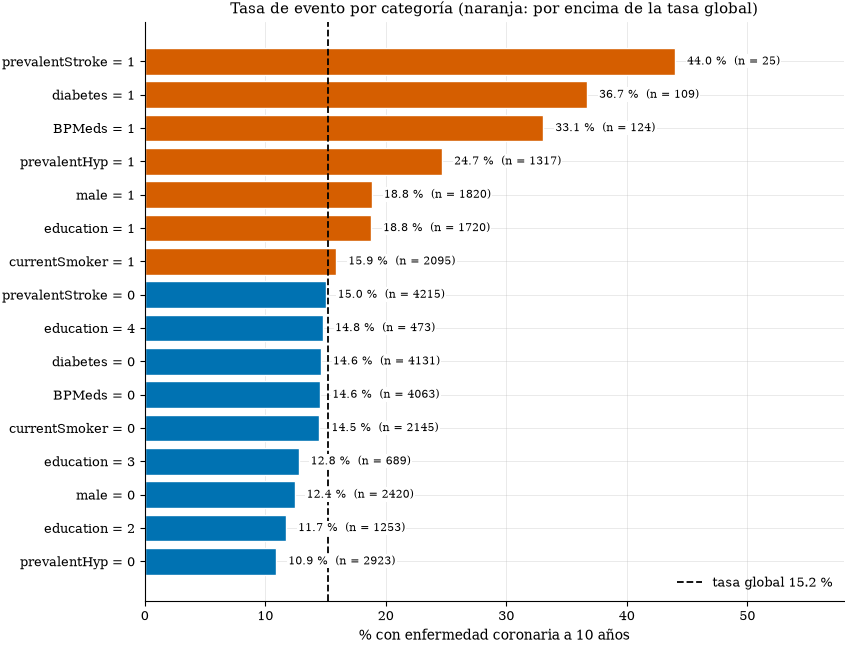

In [16]:
filas = []
for col in BIN + ORD:
    g = raw.groupby(col)[TARGET].agg(n="size", tasa="mean")
    for k, r in g.iterrows():
        filas.append({"variable": col, "categoría": str(int(k)) if col != "education" else str(int(k)), "n": int(r["n"]), "tasa": r["tasa"]})
tasas = pd.DataFrame(filas).sort_values("tasa").reset_index(drop=True)
tasas["etiqueta"] = tasas["variable"] + " = " + tasas["categoría"]
global_ = raw[TARGET].mean()

fig, ax = plt.subplots(figsize=(8.5, 6.5))
colores_bar = [C1 if t > global_ else C0 for t in tasas["tasa"]]
ax.barh(tasas["etiqueta"], 100 * tasas["tasa"], color=colores_bar, edgecolor="white")
for i, (t, n) in enumerate(zip(tasas["tasa"], tasas["n"])):
    ax.text(100 * t + 1, i, f"{100*t:.1f} %  (n = {n})", va="center", fontsize=8,
            bbox=dict(facecolor="white", edgecolor="none", pad=1.0))
ax.axvline(100 * global_, color="black", ls="--", lw=1.3, label=f"tasa global {100*global_:.1f} %")
ax.set_xlim(0, 58); ax.set_xlabel("% con enfermedad coronaria a 10 años")
ax.set_title("Tasa de evento por categoría (naranja: por encima de la tasa global)")
ax.legend(loc="lower right")
guardar(fig, "06-tasa-por-categoria.png")

Aquí aparecen las señales más fuertes de todo el dataset, más fuertes incluso que las variables
numéricas continuas:

* **`prevalentStroke = 1` (44,0 %, n = 25)**: la tasa más alta del conjunto, casi 3 veces la
  tasa global — pero con sólo 25 casos, el intervalo de confianza es muy amplio; es una señal
  fuerte y clínicamente plausible (un ACV previo es un marcador directo de enfermedad vascular),
  pero estadísticamente frágil.
* **`diabetes = 1` (36,7 %, n = 109)** y **`BPMeds = 1` (33,1 %, n = 124)**: ambas duplican
  ampliamente la tasa de quienes no las presentan (14,6 % y 14,6 % respectivamente). Tiene
  sentido: son condiciones que ya reflejan daño metabólico o vascular preexistente.
  Sección 6.3 discute que **están parcialmente definidas por otras variables del propio dataset**.
* **`prevalentHyp = 1` (24,7 % frente a 10,9 %)**: con 1 317 casos (31 % de la muestra), es la
  variable binaria más frecuente con una señal fuerte y estadísticamente sólida.
* **`male = 1` (18,8 % frente a 12,4 % en mujeres)**: una brecha real entre sexos.
* **`education`**: la relación no es monótona (18,8 % → 11,7 % → 12,8 % → 14,8 % de la categoría 1
  a la 4), pero el patrón general — la categoría educativa más baja tiene la tasa más alta —
  es consistente con el gradiente socioeconómico de salud cardiovascular documentado en la
  literatura epidemiológica.
* **`currentSmoker` (15,9 % frente a 14,5 %)** es, sorprendentemente, la señal **más débil de
  todas las binarias** — una diferencia casi nula pese a ser uno de los factores de riesgo
  cardiovascular más establecidos en medicina. Se examina en el punto siguiente.

### 6.3 Correlaciones: por qué el tabaquismo "no se ve" y qué variables son redundantes

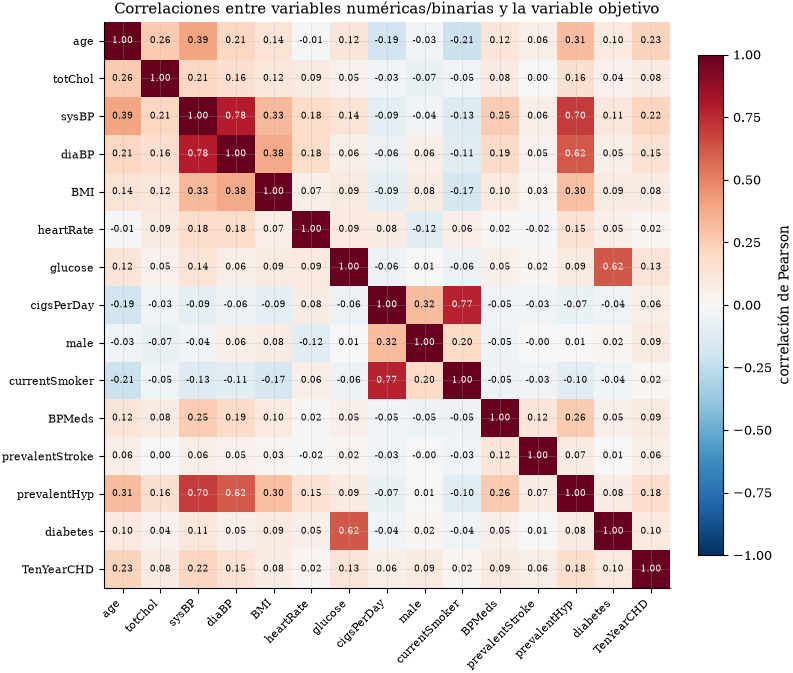

In [17]:
corr = raw[NUM + BIN + [TARGET]].corr()

fig, ax = plt.subplots(figsize=(8, 7))
im = ax.imshow(corr, cmap="RdBu_r", vmin=-1, vmax=1)
ax.set_xticks(range(len(corr))); ax.set_xticklabels(corr.columns, rotation=45, ha="right", fontsize=8)
ax.set_yticks(range(len(corr))); ax.set_yticklabels(corr.index, fontsize=8)
for i in range(len(corr)):
    for j in range(len(corr)):
        v = corr.iloc[i, j]
        ax.text(j, i, f"{v:.2f}", ha="center", va="center", fontsize=6.5, color="white" if abs(v) > 0.6 else "black")
fig.colorbar(im, ax=ax, shrink=0.8, label="correlación de Pearson")
ax.set_title("Correlaciones entre variables numéricas/binarias y la variable objetivo")
guardar(fig, "07-heatmap.png")

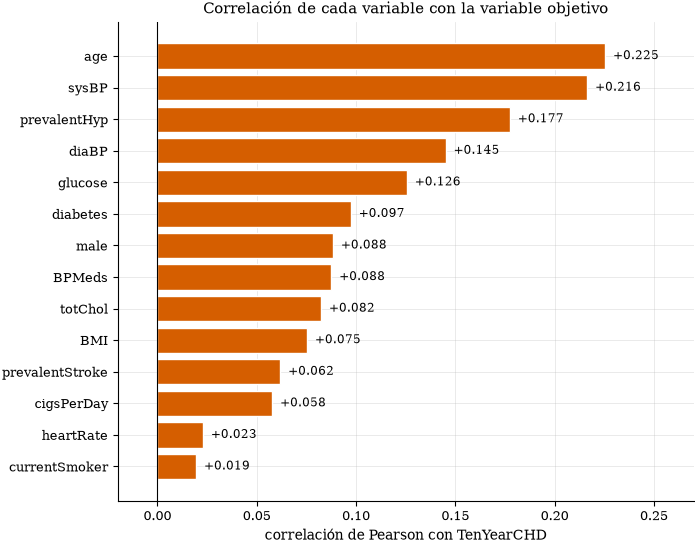

In [18]:
corr_target = raw[NUM + BIN].corrwith(raw[TARGET]).sort_values()
fig, ax = plt.subplots(figsize=(7, 5.5))
ax.barh(corr_target.index, corr_target.values, color=[C1 if v > 0 else C0 for v in corr_target.values], edgecolor="white")
for i, v in enumerate(corr_target.values):
    ax.text(v + 0.004, i, f"{v:+.3f}", va="center", fontsize=8.5)
ax.axvline(0, color="black", lw=0.8); ax.set_xlim(-0.02, 0.27)
ax.set_xlabel("correlación de Pearson con TenYearCHD")
ax.set_title("Correlación de cada variable con la variable objetivo")
guardar(fig, "08-correlacion-con-target.png")

In [19]:
# pares de variables explicativas con mayor correlación entre sí (colinealidad / redundancia estructural)
cf = raw[NUM + BIN].corr()
pares = (cf.where(np.triu(np.ones(cf.shape, dtype=bool), k=1))
           .stack().rename("r").reset_index()
           .rename(columns={"level_0": "variable A", "level_1": "variable B"}))
pares["|r|"] = pares["r"].abs()
pares.sort_values("|r|", ascending=False).head(8).drop(columns="|r|").round(3).reset_index(drop=True)

,variable A,variable B,r
0,sysBP,diaBP,0.784
1,cigsPerDay,currentSmoker,0.770
2,sysBP,prevalentHyp,0.697
3,glucose,diabetes,0.618
4,diaBP,prevalentHyp,0.616
5,age,sysBP,0.394
6,diaBP,BMI,0.377
7,sysBP,BMI,0.327


**Con la variable objetivo**, el ranking confirma lo visto antes pero con una escala comprimida:
la correlación más alta es apenas 0,225 (`age`), seguida de `sysBP` (0,216), `prevalentHyp`
(0,177), `diaBP` (0,145) y `glucose` (0,126). **Ninguna variable individual supera 0,23.** Esto
es, en sí mismo, un hallazgo importante y coherente con la literatura: el riesgo cardiovascular a
10 años es **multifactorial** — no existe un único factor que lo determine, hace falta combinar
varios. Es también la razón por la cual los scores de riesgo clínico (como el propio Framingham
Risk Score) combinan seis a ocho variables mediante un modelo, no un único umbral, y por la cual
la literatura reporta un desempeño de estos modelos con AUC entre 0,70 y 0,78 en validaciones
externas [3] — un techo de desempeño que conviene fijar como expectativa realista desde ahora
para la Entrega 2.

**El caso `currentSmoker` (r = 0,019, la correlación más débil del conjunto).** Contradice lo que
cualquiera esperaría del tabaquismo. La explicación más plausible no es que fumar sea inocuo, sino
una limitación de la correlación bivariada: (a) el efecto del tabaco es **dosis-dependiente** —
`cigsPerDay` sí tiene una correlación algo mayor (0,058) — y una variable binaria "fuma sí/no"
mezcla fumadores ligeros y de 70 cigarrillos/día en la misma categoría; (b) puede haber
**censura por mortalidad competitiva**: en una cohorte seguida desde los años 60-70, algunos
fumadores intensos pueden haber fallecido por otras causas antes de completar los 10 años de
seguimiento, lo que atenúa la asociación observada. Es un ejemplo claro de por qué una correlación
lineal simple puede ocultar un efecto real, y un argumento adicional a favor de complementar el
modelo lineal con uno no lineal capaz de capturar dosis-respuesta e interacciones (pregunta de
investigación 2).

**Entre variables explicativas**, aparecen correlaciones altas que son en gran medida
**estructurales, no descubrimientos**: `sysBP`–`diaBP` (0,784, ambas miden presión arterial),
`cigsPerDay`–`currentSmoker` (0,770, por construcción: quien no fuma tiene 0 cigarrillos),
`sysBP`–`prevalentHyp` (0,697) y `diaBP`–`prevalentHyp` (0,616, `prevalentHyp` es esencialmente
una versión umbralizada de la presión arterial) y `glucose`–`diabetes` (0,618, mismo caso con la
glucosa). Esto importa para el modelado: `prevalentHyp`, `diabetes` y `BPMeds` no son señales
independientes de `sysBP`/`diaBP`/`glucose`, sino resúmenes clínicos parcialmente redundantes con
ellas. Un modelo lineal sin regularización repartiría el mismo efecto entre variables
correlacionadas de forma inestable; la regularización L2 (o L1 para selección) es la respuesta
natural, y se evaluará explícitamente en la Entrega 2.

Un último patrón, más discreto pero visible en el mapa de calor, es el único bloque con
correlaciones **negativas** apreciables: `age` con `cigsPerDay` (−0,19) y con `currentSmoker`
(−0,21). En esta cohorte, los participantes de mayor edad fuman menos y en menor cantidad. Es
compatible con dos explicaciones no excluyentes: un efecto de cohorte generacional (los
participantes mayores nacieron antes y adoptaron el hábito con menor frecuencia que las
generaciones más jóvenes de la muestra) o abandono del tabaco con la edad, frecuente cuando ya
han aparecido síntomas o advertencias médicas. Cualquiera sea la causa, refuerza el punto anterior
sobre `currentSmoker`: su relación con el riesgo no es simple, porque además de diluirse por la
falta de dosis-respuesta, está parcialmente confundida con la edad — la variable individual más
predictiva del conjunto.

### 6.4 Edad, presión y sexo

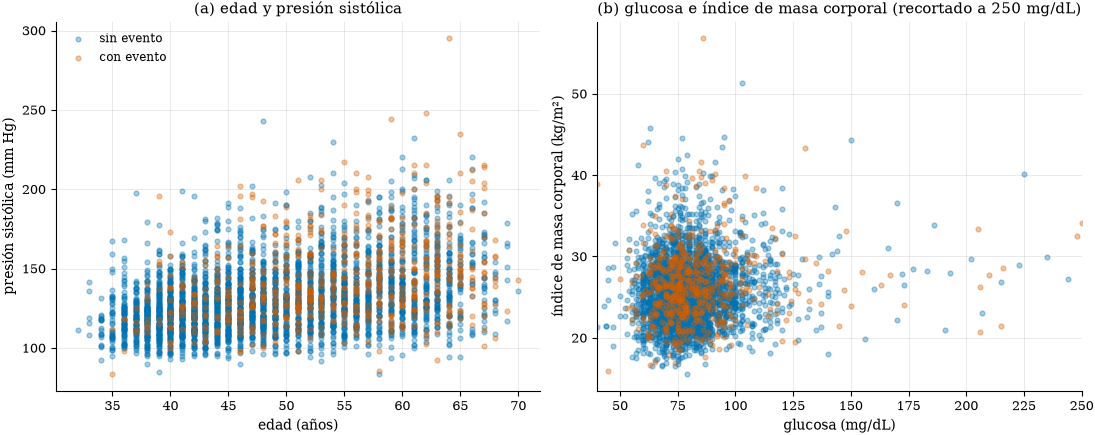

In [20]:
fig, ax = plt.subplots(1, 2, figsize=(11, 4.4))
for cls, color, lab in [(0, C0, "sin evento"), (1, C1, "con evento")]:
    d = raw[raw[TARGET] == cls]
    ax[0].scatter(d["age"], d["sysBP"], s=12, alpha=0.35, color=color, label=lab)
ax[0].set_xlabel(ETIQUETAS["age"]); ax[0].set_ylabel(ETIQUETAS["sysBP"]); ax[0].set_title("(a) edad y presión sistólica")
ax[0].legend(fontsize=8.5)

d = raw.dropna(subset=["glucose"])
for cls, color, lab in [(0, C0, "sin evento"), (1, C1, "con evento")]:
    sub = d[d[TARGET] == cls]
    ax[1].scatter(sub["glucose"], sub["BMI"], s=12, alpha=0.35, color=color, label=lab)
ax[1].set_xlim(40, 250); ax[1].set_xlabel(ETIQUETAS["glucose"]); ax[1].set_ylabel(ETIQUETAS["BMI"])
ax[1].set_title("(b) glucosa e índice de masa corporal (recortado a 250 mg/dL)")
guardar(fig, "09-scatter-clase.png")

El panel **(a)** muestra que el riesgo se concentra en la esquina de mayor edad y mayor presión:
los puntos naranjas (con evento) se agrupan visiblemente hacia arriba y a la derecha, aunque con
superposición considerable — coherente con que ninguna de las dos variables por separado alcanza
una correlación mayor a 0,23. El panel **(b)** no muestra una separación tan clara entre glucosa e
IMC; la mayoría de los casos con evento tiene valores de glucosa moderados (por debajo de 120),
y sólo una franja de valores muy altos (compatible con diabetes) se asocia visualmente con más
naranja. Ninguna de las dos combinaciones separa las clases con nitidez — otra confirmación visual de que
hace falta combinar muchas variables, no una o dos.

### 6.5 Sexo y edad

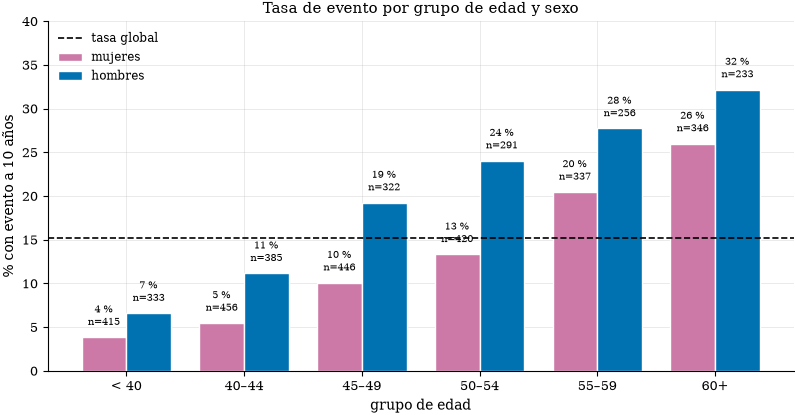

In [21]:
grupos = pd.cut(raw["age"], bins=[0, 40, 45, 50, 55, 60, 100], labels=["< 40", "40–44", "45–49", "50–54", "55–59", "60+"])
tab = raw.groupby([grupos, "male"], observed=True)[TARGET].agg(n="size", tasa="mean").unstack("male")

fig, ax = plt.subplots(figsize=(8, 4.2))
x = np.arange(len(tab)); w = 0.38
for i, (sexo, color, lab) in enumerate([(0, "#CC79A7", "mujeres"), (1, "#0072B2", "hombres")]):
    vals = 100 * tab[("tasa", sexo)]
    ax.bar(x + (i - 0.5) * w, vals, width=w, color=color, edgecolor="white", label=lab)
    for xi, v, n in zip(x + (i - 0.5) * w, vals, tab[("n", sexo)]):
        ax.text(xi, v + 1, f"{v:.0f} %\nn={n}", ha="center", va="bottom", fontsize=7.5)
ax.axhline(100 * raw[TARGET].mean(), color="black", ls="--", lw=1.2, label="tasa global")
ax.set_xticks(x); ax.set_xticklabels(tab.index); ax.set_xlabel("grupo de edad")
ax.set_ylim(0, 40); ax.set_ylabel("% con evento a 10 años")
ax.set_title("Tasa de evento por grupo de edad y sexo"); ax.legend(loc="upper left", fontsize=8.5)
guardar(fig, "10-sexo-edad.png")

La tasa de evento crece de forma casi monótona con la edad en ambos sexos (de 3,9 %/6,6 % en
menores de 40 a 26,0 %/32,2 % en mayores de 60, mujeres/hombres respectivamente), y los hombres
superan a las mujeres en **todos** los grupos de edad, aunque la brecha se estrecha con la edad
(de 6,6 % frente a 3,9 % —una razón de 1,7— en menores de 40, a 32,2 % frente a 26,0 % —una razón
de 1,2— en mayores de 60). El patrón es consistente con la literatura clínica: el riesgo
cardiovascular femenino se acerca al masculino después de la menopausia. Ambos sexos tienen
tamaños de muestra razonables en casi todos los grupos de edad (el más pequeño, mujeres < 40, con
415 casos), lo que da confianza a las comparaciones desagregadas que se harán en la Entrega 2.

## 7. Sesgo y *data leakage*

### 7.1 Sesgos del conjunto de datos

| Riesgo | Evidencia en el EDA | Consecuencia | Control previsto (P2) |
| --- | --- | --- | --- |
| **Sesgo étnico/geográfico** | Cohorte reclutada en un único pueblo de Nueva Inglaterra a fines de los 40, históricamente poco diversa | La literatura documenta que el score de Framingham calibra mal en poblaciones afroamericanas y sobreestima el riesgo en hispanas, japonesas-americanas y mujeres nativo-americanas [5][6] | Declararlo explícitamente como limitación de validez externa; no se puede corregir con estos datos |
| **Sesgo temporal** | 49,4 % de fumadores activos (hoy, ronda 11-12 % en EE. UU.); datos de mediados del s. XX | Los pesos que el modelo aprenda para `currentSmoker`/`cigsPerDay` reflejan una prevalencia y una exposición muy distintas a las actuales; los factores de riesgo relativos pueden mantenerse, pero las tasas absolutas no son trasladables a una población de hoy | Declararlo como limitación; discutir riesgo relativo vs. absoluto |
| **Sesgo demográfico (sexo)** | Brecha de tasa de evento en todos los grupos de edad (18,8 % vs 12,4 % global) | Riesgo de menor sensibilidad del modelo en el grupo con menos eventos positivos en números absolutos | Métricas desagregadas por sexo en P2 |
| **Sesgo socioeconómico** | `education` (proxy de nivel socioeconómico) con tasa más alta en la categoría más baja (18,8 % vs 11,7-14,8 %) | Un modelo que use `education` puede reproducir, no sólo describir, una desigualdad social | Discutir si se incluye o no como predictor, y con qué justificación |
| **Rango de edad y tipo de muestra** | 32–70 años, examen de seguimiento de una cohorte comunitaria, no una muestra clínica | El modelo no está pensado ni validado para poblaciones ya enfermas o fuera de ese rango etario | Documentar el dominio de aplicación previsto (tamizaje poblacional adulto) |

### 7.2 Riesgos de *data leakage*

1. **Leakage estadístico en el preprocesamiento.** Como en cualquier pipeline, la imputación de
   `glucose`, `totChol`, `BMI`, etc., y el escalado deben ajustarse **sólo** con el conjunto de
   entrenamiento, dentro de un `ColumnTransformer`/`Pipeline`, y repetirse en cada pliegue de la
   validación cruzada — la regla ya usada en las sesiones 01c/01e del curso.

2. **Redundancia estructural entre predictores (sección 6.3).** `prevalentHyp`, `diabetes` y
   `BPMeds` están, por definición clínica, parcialmente determinadas por `sysBP`/`diaBP`/`glucose`.
   No es *leakage* en sentido estricto — todas se miden en el mismo examen basal, antes del
   desenlace —, pero sí implica que el modelo puede sobreponderar efectivamente la misma señal de
   presión o glucosa varias veces si no se regulariza. Se evaluará explícitamente el efecto de
   incluir o excluir estas variables derivadas.

3. **Ausencia de leakage temporal/clínico, por diseño.** **Todas** las 15 variables se miden en el
   examen basal, **antes** de la ventana de seguimiento de 10 años en la que ocurre (o no) el
   desenlace. Ninguna variable presupone un examen posterior ni una sospecha clínica previa: por
   construcción, no puede haber fuga de información "del futuro hacia el pasado".

4. **El indicador de faltante no parece ser un atajo hacia el objetivo.** La sección 3.3 mostró
   que el faltante en `glucose` (el más frecuente) se asocia más al sexo que al desenlace, y sólo
   `BPMeds` muestra un indicio débil de asociación con el objetivo. Aun así, se probará en P2 si
   añadir indicadores de faltante mejora o no el desempeño, sin asumir de antemano que son
   inocuos.

## 8. Conclusiones del EDA y propuesta de siguientes pasos

### 8.1 Hallazgos principales

**Sobre el dataset.** 4 240 participantes de una cohorte comunitaria (no clínica), 15 variables de
examen basal y un objetivo binario prospectivo a 10 años. Sin duplicados; con faltantes reales
(13,7 % de las filas, concentrados en `glucose`) cuyo patrón se acerca más a MAR que a MNAR: el faltante
no parece codificar por sí mismo el desenlace.
El objetivo está fuertemente desbalanceado (15,2 % / 84,8 %), lo que exige métricas más allá de la
exactitud y atención a la calibración de probabilidades.

**Sobre la calidad.** No se detectan valores imposibles ni inconsistencias internas (la presión
diastólica nunca supera a la sistólica, el estatus de fumador es siempre coherente con el consumo
declarado). Los únicos valores extremos (glucosa hasta 394, IMC hasta 56,8) son clínicamente
plausibles y se conservan.

**Sobre las relaciones con el riesgo.** Edad y presión sistólica son, por un margen claro, las
variables más discriminantes (correlación 0,225 y 0,216 respectivamente), seguidas de
`prevalentHyp`, `diaBP` y `glucose`. Ninguna variable individual supera una correlación de 0,23 —
consistente con que el riesgo cardiovascular a 10 años es multifactorial, y con el desempeño
reportado en la literatura para modelos de este tipo (AUC 0,70–0,78). El tabaquismo binario
muestra una asociación sorprendentemente débil, probablemente por su naturaleza dosis-dependiente
y por efectos de cohorte, mientras que `cigsPerDay` (la versión continua) sí discrimina algo más.
Varias variables clínicas (`prevalentHyp`, `diabetes`) son parcialmente redundantes con las
continuas que las originan (presión, glucosa).

**Sobre sesgo y leakage.** El conjunto tiene sesgos documentados de raza/etnia (validado en la
literatura), época (prevalencia de tabaquismo muy superior a la actual), sexo y nivel
socioeconómico. Por diseño, no hay riesgo de leakage temporal/clínico: todas las variables
preceden al desenlace, al provenir de un único examen basal seguido en el tiempo.

### 8.2 Respuesta preliminar a la pregunta de investigación 1

Con datos exclusivamente de un chequeo de rutina (sin exámenes invasivos ni de esfuerzo), las
variables más informativas son la edad y la presión arterial, seguidas de la condición
hipertensiva previa y la glucosa — todas medibles en una consulta estándar. Esto confirma que el
problema de tamizaje planteado en la sección 0 es, en principio, abordable con este tipo de datos,
aunque con un techo de desempeño individual bajo por variable, que sólo un modelo multivariado
puede superar parcialmente.

### 8.3 Propuesta para la Entrega 2

1. **Partición.** *Split* estratificado 80/20 con semilla fija (crítico dado el desbalance del
   15 %); selección de modelos con validación cruzada estratificada de 5 pliegues.
2. **Preprocesamiento.** Imputación de `glucose`/`totChol`/`BMI`/`BPMeds`/`cigsPerDay`/`education`
   condicionada en variables observadas (p. ej., por sexo, dado el patrón encontrado en 3.3);
   `RobustScaler` para las numéricas de cola larga (`glucose` en particular); evaluación de incluir
   o excluir las variables redundantes (`prevalentHyp`, `diabetes`, `BPMeds`) frente a sus
   continuas de origen.
3. **Manejo del desbalance.** Comparar `class_weight="balanced"` con remuestreo (submuestreo de la
   clase mayoritaria o sobremuestreo tipo SMOTE) en validación cruzada, evitando aplicarlo antes
   del *split*.
4. **Baseline.** `DummyClassifier(strategy="most_frequent")` (84,8 % de exactitud, explícitamente
   inútil) y una regresión logística de una sola variable (`age`) como referencia informada.
5. **Modelos a comparar.** Regresión logística regularizada (L2, en la línea del Framingham Risk
   Score original) frente a un modelo no lineal (Random Forest o Gradient Boosting), comparando
   además contra el desempeño de referencia de la literatura (AUC 0,70–0,78) [3].
6. **Métricas.** ROC-AUC y **PR-AUC** (más informativa bajo este desbalance) para la selección;
   recall, precisión, F1 y matriz de confusión en prueba; **curva de calibración** de las
   probabilidades predichas, justificada por tratarse de un score de riesgo y no de un diagnóstico.
7. **Equidad.** Métricas desagregadas por sexo y por nivel educativo; discusión explícita de si
   `education` debe incluirse como predictor dado su rol de proxy socioeconómico.
8. **Interpretación.** Coeficientes de la logística (razones de riesgo) comparados con los
   coeficientes históricos del Framingham Risk Score; importancia de variables por permutación en
   el modelo no lineal; análisis de los falsos negativos (personas de alto riesgo no detectadas).

## 9. Referencias

[1] T. R. Dawber, G. F. Meadors y F. E. Moore Jr., "Epidemiological approaches to heart disease:
the Framingham Study," *American Journal of Public Health*, vol. 41, n.º 3, pp. 279–286, 1951.

[2] Kaggle, "Framingham Heart Study Dataset" (subconjunto redistribuido para docencia).
Disponible: https://www.kaggle.com/datasets/aasheesh200/framingham-heart-study-dataset

[3] Validaciones externas del Framingham Risk Score reportan AUC/c-statistic entre 0,70 y 0,78 en
distintas cohortes: p. ej. C-statistic 0,72 (Canadá), AUC 0,75-0,77 (Asia), AUC 78,4/74,9
(Alemania, mujeres/hombres). Ver revisiones en PMC (National Library of Medicine).

[4] Organización Mundial de la Salud, "Cardiovascular diseases (CVDs) — Fact sheet," 2021.
Disponible: https://www.who.int/news-room/fact-sheets/detail/cardiovascular-diseases-(cvds)

[5] D. Gaziano *et al.*, "Prediction of cardiovascular death in racial/ethnic minorities using
Framingham risk factors," *Circulation: Cardiovascular Quality and Outcomes*, 2009.

[6] "The Role of Race in Cardiovascular Disease Risk Prediction," *PMC*, 2024. Discute la
limitada generalizabilidad del score de Framingham fuera de poblaciones blancas.

[7] F. Pedregosa *et al.*, "Scikit-learn: Machine Learning in Python," *Journal of Machine
Learning Research*, vol. 12, pp. 2825–2830, 2011.